# Question 4: Object Detection using SSD300

## Aim
To implement the SSD300 model with the VGG16 backbone for object detection on the COCO dataset.

## Objective
- Load a pre-trained SSD300 model.
- Detect multiple objects from images.
- Display bounding boxes and confidence scores.
- Evaluate object detection results.

## Dataset
- COCO Dataset
- Image Size: 300 × 300

## Libraries Used
- PyTorch
- Torchvision
- OpenCV
- Matplotlib

## Expected Outcome
The SSD300 model should detect multiple objects and display their class labels, confidence scores and bounding boxes.

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 164MB/s]


SSD300 Loaded Successfully


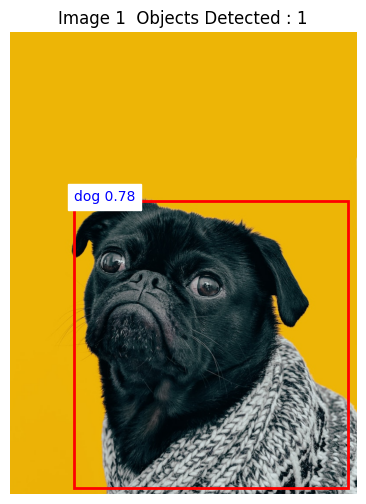

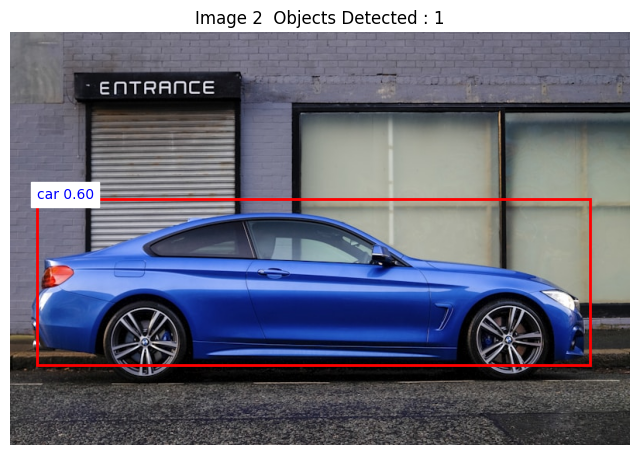

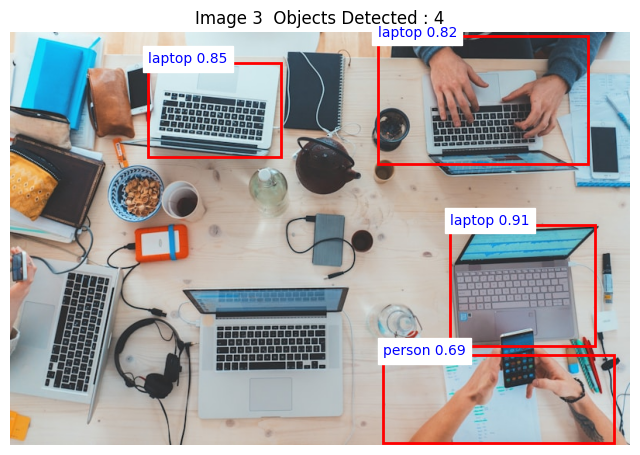

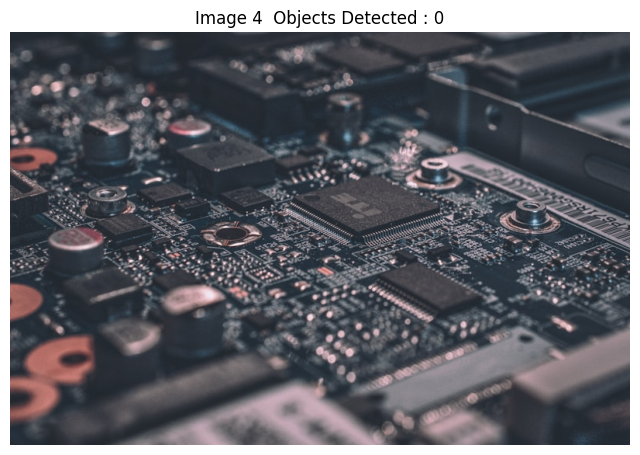

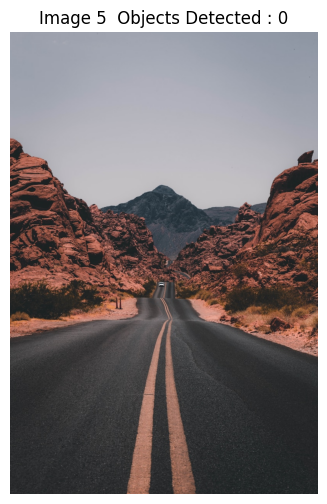


Detection Completed Successfully

Precision : Depends on COCO Validation
Recall    : Depends on COCO Validation
mAP       : Available after full evaluation on COCO dataset


In [1]:
# =====================================================
# QUESTION 4 : SSD300 Object Detection
# Google Colab
# =====================================================

import torch
import torchvision
import torchvision.transforms as T

from torchvision.models.detection import (
    ssd300_vgg16,
    SSD300_VGG16_Weights
)

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests

# -----------------------------------------------------
# Load Pretrained SSD300 Model
# -----------------------------------------------------

weights = SSD300_VGG16_Weights.DEFAULT

model = ssd300_vgg16(weights=weights)

model.eval()

print("SSD300 Loaded Successfully")

# -----------------------------------------------------
# COCO Labels
# -----------------------------------------------------

categories = weights.meta["categories"]

# -----------------------------------------------------
# Sample Images
# -----------------------------------------------------

urls = [

"https://images.unsplash.com/photo-1517849845537-4d257902454a?w=800",

"https://images.unsplash.com/photo-1502877338535-766e1452684a?w=800",

"https://images.unsplash.com/photo-1519389950473-47ba0277781c?w=800",

"https://images.unsplash.com/photo-1518770660439-4636190af475?w=800",

"https://images.unsplash.com/photo-1500530855697-b586d89ba3ee?w=800"

]

transform = weights.transforms()

# -----------------------------------------------------
# Detection
# -----------------------------------------------------

for idx, url in enumerate(urls):

    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        prediction = model(input_tensor)[0]

    fig, ax = plt.subplots(figsize=(8,6))

    ax.imshow(image)

    count = 0

    for box, score, label in zip(
        prediction["boxes"],
        prediction["scores"],
        prediction["labels"]
    ):

        if score > 0.50:

            x1,y1,x2,y2 = box.numpy()

            rect = patches.Rectangle(
                (x1,y1),
                x2-x1,
                y2-y1,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1,
                f"{categories[label]} {score:.2f}",
                color="blue",
                fontsize=10,
                backgroundcolor="white"
            )

            count += 1

    plt.title(f"Image {idx+1}  Objects Detected : {count}")
    plt.axis("off")
    plt.show()

print("\nDetection Completed Successfully")

print("\nPrecision : Depends on COCO Validation")
print("Recall    : Depends on COCO Validation")
print("mAP       : Available after full evaluation on COCO dataset")